In [2]:
import sys
import os
from pathlib import Path

package_path = Path(os.path.abspath("")).parent


Image shape: (5000, 4916, 3)
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 100 out of 140 total masks.
Chosen parameters: eps=540.0, min_samples=1
Filtering completed with chosen parameters: (np.float64(540.0), 1)


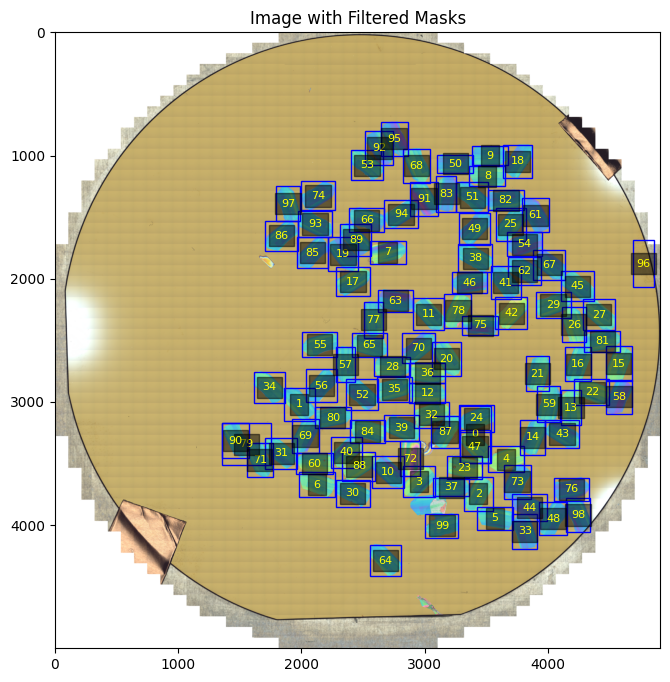

Number of masks identified: 100


In [ ]:
from section_identification.preprocess import preprocess_image
from section_identification.filtering import filtering
from section_identification.section_detector import automatic_identification
from section_identification.preprocess import gpu_image


image1 = package_path / "images/example1.png"
image2 = package_path / "images/example2.png"
image3 = package_path / "images/example3.png"
image4 = package_path / "images/example4.png"
jellyfish = package_path / "images/jellyfish.png"


image5 = package_path / "images/Coronal Sections/wafer1_250nm_100sections_0.08mm-s_RGB.png"
image6 = package_path / "images/Coronal Sections/wafer1_250nm_100sections_0.08mm-s.png"
image7 = package_path / "images/Coronal Sections/wafer2_250nm_100sections_0.08mm-s_RGB.png"
image8 = package_path / "images/Coronal Sections/wafer2_250nm_100sections_0.08mm-s.png"
image9 = package_path / "images/Coronal Sections/wafer3_250nm_100sections_0.08mm-s.png"
image10 = package_path / "images/Coronal Sections/wafer3_250nm_100sections_0.08mm-s_RGB.png"
image11 = package_path / "images/Coronal Sections/wafer4_250nm_100sections_0.08mm-s.png"


# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 

# To use gpu, 1) uncomment next line; 2) uncomment device="cuda";
#image = gpu_image(image6) # WARNING: there will be loss of quality in the image and therefore poorer segmentation 

# Write filtering=True to only identify sections
masks = automatic_identification(image11, checkpoint=checkpoint, compress=False, apply_filtering=True,
                                 min_mask_region_area=250, points_per_side=128,  #device="cuda"
                                 )
print(f"Number of masks identified: {len(masks)}")


In [13]:
from section_identification.interactive import run_sam_interactive

new_masks, stored_masks, fiducials = run_sam_interactive(image4, checkpoint, masks, model_type="vit_h", device="cpu")

Quantized ONNX model already exists: c:\Users\Lab\Documents\section_targeting\section_identification\images\example4_files/example4_onnx_quantized.onnx
[Info] Embedding already exists: c:\Users\Lab\Documents\section_targeting\section_identification\images\example4_files/example4_embedding.npy
Image size: 5000x4999 (width x height), samScale: 0.205
Processing mask 1/9
Processing mask 2/9
Processing mask 3/9
Processing mask 4/9
Processing mask 5/9
Processing mask 6/9
Processing mask 7/9
Processing mask 8/9
Processing mask 9/9
[Info] Starting interactive segmentation. Move the mouse over the image to update mask.
[Info] Exiting interactive segmentation.


Exported mask coordinates to c:\Users\Lab\Documents\section_targeting\section_identification\images\example4_files\example4_mask_coordinates.csv


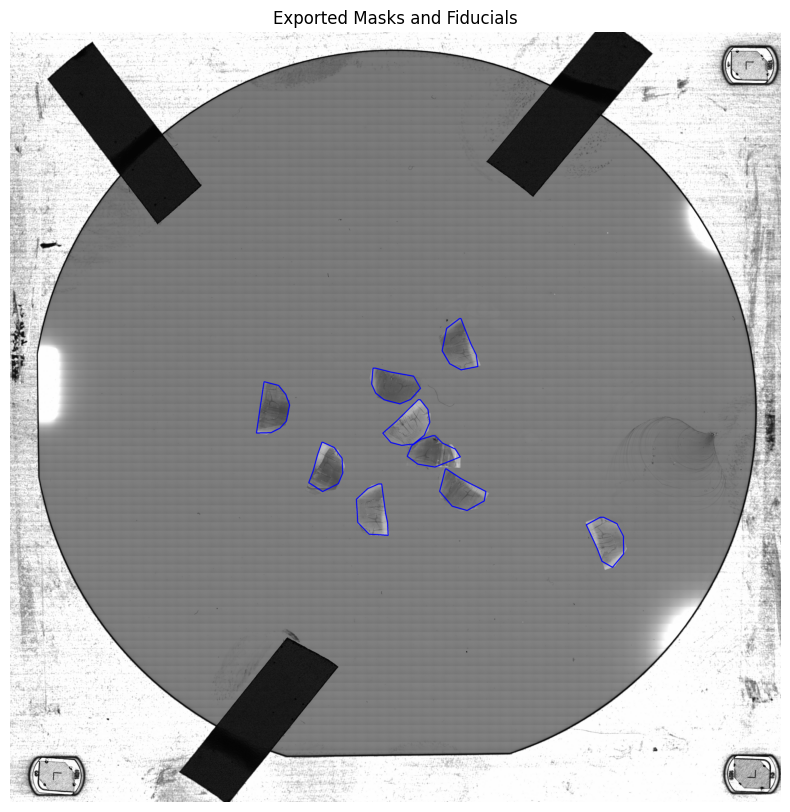

'c:\\Users\\Lab\\Documents\\section_targeting\\section_identification\\images\\example4_files\\example4_mask_coordinates.csv'

In [15]:
from section_identification.export import export_mask_coordinates
export_mask_coordinates(image4, new_masks, stored_masks, fiducials, visualize=True, sample_points=10)